--- Model Performance ---
Accuracy (R2 Score): 67.12%
Mean Absolute Error: 179,725.72


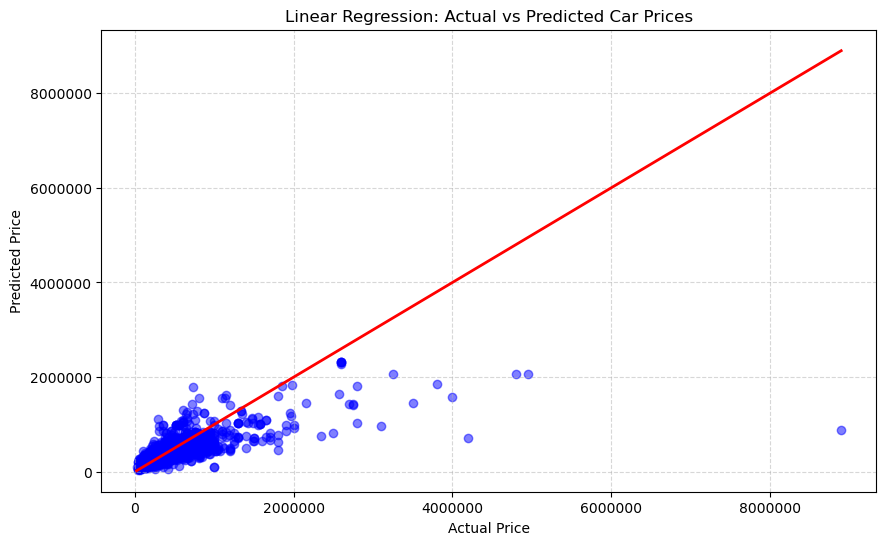

In [30]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Load the Dataset
df = pd.read_csv("https://www.dropbox.com/scl/fi/i5rdcx9dm1mnc57wra7wz/CAR-DETAILS-FROM-CAR-DEKHO.csv?rlkey=7t5zt4gng1dlxmegwh7b59usq&st=mi6jvsyh&dl=1")
df.head()

# 2. Feature Engineering & Preprocessing
# Convert 'year' to 'car_age' for better linear interpretation
current_year = 2026 
df['car_age'] = current_year - df['year']

# Drop columns that are either redundant or too unique for basic regression
df = df.drop(['name', 'year'], axis=1)

# Automatically convert text categories (Fuel, Seller Type, etc.) into numbers (0s and 1s)
df_processed = pd.get_dummies(df, drop_first=True)

# 3. Split Features (X) and Target (y)
X = df_processed.drop('selling_price', axis=1)

# Log-transform the target price to help the linear model fit the data better
y = np.log(df_processed['selling_price'])

# 4. Train/Test Split (70% for training, 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. Scale the Numerical Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 7. Make Predictions on the Test Set
y_pred_log = model.predict(X_test_scaled)

# Reverse the log transformation to get actual currency values
y_test_real = np.exp(y_test)
y_pred_real = np.exp(y_pred_log)

# 8. Evaluate Model Performance
r2 = r2_score(y_test, y_pred_log)
mae = mean_absolute_error(y_test_real, y_pred_real)

print("--- Model Performance ---")
print(f"Accuracy (R2 Score): {r2 * 100:.2f}%")
print(f"Mean Absolute Error: {mae:,.2f}")

# 9. Generate the Simple Graph
plt.figure(figsize=(10, 6))

# Plot the predicted vs actual prices
plt.scatter(y_test_real, y_pred_real, alpha=0.5, color='blue')

# Draw the red "perfect prediction" line
plt.plot([y_test_real.min(), y_test_real.max()], 
         [y_test_real.min(), y_test_real.max()], 
         color='red', linewidth=2)

plt.title('Linear Regression: Actual vs Predicted Car Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

# Prevent the graph from using scientific notation (e.g., 1e6)
plt.ticklabel_format(style='plain', axis='both')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()